In [1]:
import logging

import shap

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
shap.initjs()

In [2]:
from darts.datasets import AirPassengersDataset
from darts.explainability.shap_explainer import ShapExplainer
from darts.models import LinearRegressionModel

series = AirPassengersDataset().load()
model = LinearRegressionModel(lags=12)
model.fit(series[:-36])
shap_explain = ShapExplainer(model)
results = shap_explain.explain()
results.get_explanation(horizon=1)

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)
INFO:darts.explainability.shap_explainer:The shap method used is of type: <class 'shap.explainers._linear.LinearExplainer'>
/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


,#Passengers_target_lag-12,#Passengers_target_lag-11,#Passengers_target_lag-10,#Passengers_target_lag-9,#Passengers_target_lag-8,...,#Passengers_target_lag-5,#Passengers_target_lag-4,#Passengers_target_lag-3,#Passengers_target_lag-2,#Passengers_target_lag-1
1950-01-01,-65.154513,-31.488720,19.541674,-21.157246,23.218400,...,-19.733614,23.333699,-23.382556,33.668183,-54.867613
1950-02-01,-61.349965,-27.022281,20.214329,-22.989410,20.053631,...,-22.503077,27.294711,-26.322042,30.208373,-56.188357
1950-03-01,-52.472687,-27.979375,22.008076,-19.783123,17.114918,...,-26.426482,30.789722,-23.578521,30.949761,-51.345628
1950-04-01,-54.374961,-30.531626,18.869019,-16.805856,17.114918,...,-29.888311,27.527712,-24.166419,28.231338,-44.741908
1950-05-01,-59.447691,-26.065187,15.954179,-16.805856,19.827576,...,-26.657271,28.226714,-22.010795,24.524399,-47.383396
...,...,...,...,...,...,...,...,...,...,...,...
1957-09-01,88.929667,28.489168,-11.624684,19.379386,-20.636247,...,26.424103,-27.693455,35.995075,-55.545496,98.778949
1957-10-01,57.859194,17.323072,-19.472328,21.440570,-17.471479,...,28.039623,-43.304502,44.421603,-56.039755,71.043324
1957-11-01,35.666000,28.489168,-21.490293,18.234283,-29.904497,...,43.502458,-53.323532,44.813535,-40.470608,45.949186
1957-12-01,57.859194,31.360449,-18.351236,30.830412,-28.096058,...,53.426367,-53.789534,32.467691,-26.384238,27.458769


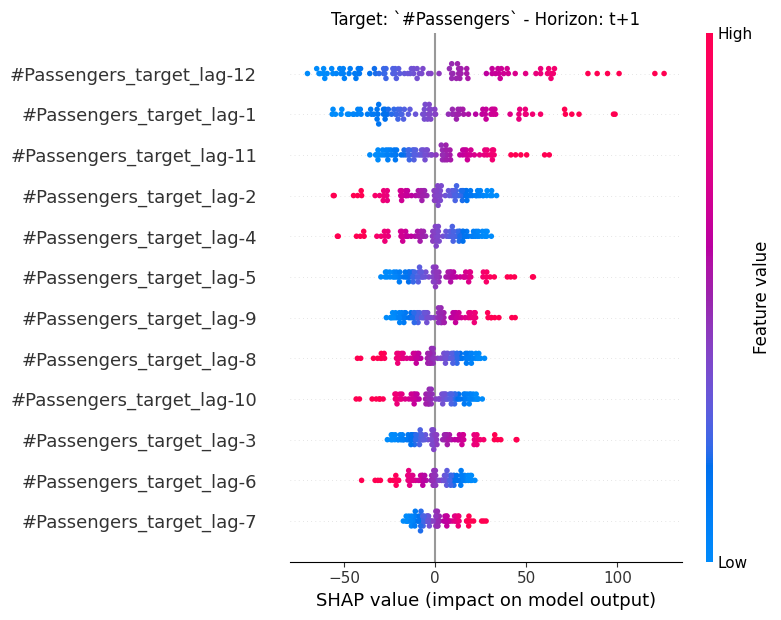

In [3]:
shap_explain.summary_plot();

In [4]:
shap_explain.force_plot_from_ts()

/Users/engs2902/Documents/code/darts/darts/utils/statistics.py:489: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  return kpss(ts.values(copy=False), regression, nlags)


In [5]:
from darts.utils.statistics import stationarity_tests

stationarity_tests(series[-36:])

np.False_

In [6]:
from darts.explainability.utils import _test_stationarity

_test_stationarity([series[-36:]])

False

In [7]:
import numpy as np

all([np.False_, np.False_])

False